# Notebook 27 — Balanced Synthetic Augmentation + Platt Scaling + Regression Gate

## Objective

Retrain the RF model with a production-grade retraining pipeline that addresses
the calibration shift identified in NB26.

## Lessons from NB25/NB26

| Attempt | SQLi added | Benign added | Result |
|---|---|---|---|
| NB25 (full) | 66,315 | 51,042 | Recall 97.3%→57.9% — vocabulary shift |
| NB26a | 4,471 | 0 | Recall 97.3%→81.2% — calibration shift |
| NB26b | 4,471 | 602 | Recall 97.3%→81.0% — still imbalanced |

Root cause: every attempt had SQLi/benign ratio different from original (37%/63%).
Adding SQLi-only examples shifts the prior, compressing all probability scores.

## Fixes applied in NB27

1. **Spanish + English prefixes** — directly covers `carritoAND`, `Vaciar carritoAND`
2. **Balanced augmentation** — synthetic benign count = synthetic SQLi × 1.7 (original ratio)
3. **class_weight=None** — matches NB07 exactly
4. **Platt scaling** — post-hoc calibration on original val set remaps probabilities
5. **Regression gate** — candidate model must beat NB07 before being accepted

## Baseline to beat (NB21, old RF, T=0.78)
- Recall: 0.9698, FP/10k: 4.29, Precision: 0.9825

> **Reproducibility note**
>
> This notebook contains intermediate experiments with both raw and calibrated
> Random Forest variants. The final SQLi model distributed with this repository
> is the raw Random Forest artefact:
>
> `models/27_rf_raw.joblib`
>
> together with:
>
> `models/27_vectorizer.joblib`
>
> The final deployment threshold is `T_HIGH = 0.81`.

## 0. Install Dependencies

In [1]:
import subprocess
subprocess.run(['pip', 'install', '-q',
                'scikit-learn', 'scipy', 'matplotlib',
                'numpy', 'pandas', 'joblib'])
print('Dependencies installed.')

Dependencies installed.


## 1. Imports & Paths

In [2]:
import os
import re
import time
import joblib
import warnings
import urllib.parse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.metrics import precision_recall_curve, auc

warnings.filterwarnings('ignore')

BASE          = os.path.expanduser('../')
BASE_DATASET  = f'{BASE}/datasets/Cleaned_SQL_Dataset.csv'
MODELS_DIR    = f'{BASE}/notebooks/results/models'
ATTACK_FILE   = f'{BASE}/logs/csic2010/anomalousTrafficTest.txt'
BENIGN_TEST   = f'{BASE}/logs/csic2010/normalTrafficTest.txt'
BENIGN_TRAIN  = f'{BASE}/logs/csic2010/normalTrafficTraining.txt'

RF_RAW_PATH   = f'{MODELS_DIR}/27_rf_raw.pkl'
RF_CAL_PATH   = f'{MODELS_DIR}/27_rf_calibrated.pkl'
VEC_PATH      = f'{MODELS_DIR}/27_vectorizer.pkl'
OLD_RF_PATH   = f'{MODELS_DIR}/07_rf_model.pkl'
OLD_VEC_PATH  = f'{MODELS_DIR}/07_vectorizer.pkl'

# Original class ratio from Cleaned_SQL_Dataset.csv
ORIGINAL_SQLI_RATIO  = 11327 / 30851   # 0.367
ORIGINAL_BENIGN_RATIO = 19524 / 30851  # 0.633
BENIGN_PER_SQLI = ORIGINAL_BENIGN_RATIO / ORIGINAL_SQLI_RATIO  # ~1.724

os.makedirs(MODELS_DIR, exist_ok=True)

print('Imports done.')
print(f'Target benign/SQLi ratio: {BENIGN_PER_SQLI:.3f}')
print()
all_ok = True
for label, path in [
    ('Base dataset',  BASE_DATASET),
    ('Old RF model',  OLD_RF_PATH),
    ('Old vectorizer', OLD_VEC_PATH),
    ('Attack file',   ATTACK_FILE),
    ('Benign test',   BENIGN_TEST),
    ('Benign train',  BENIGN_TRAIN),
]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) // 1024 if exists else 0
    status = '✅' if exists else '❌'
    print(f'  {status} {label:<16}: {size:>6} KB')
    if not exists: all_ok = False
print('\nReady.' if all_ok else '\n⚠️  Some files missing.')

Imports done.
Target benign/SQLi ratio: 1.724

  ❌ Base dataset    :      0 KB
  ❌ Old RF model    :      0 KB
  ❌ Old vectorizer  :      0 KB
  ❌ Attack file     :      0 KB
  ❌ Benign test     :      0 KB
  ❌ Benign train    :      0 KB

⚠️  Some files missing.


## 2. Generate Synthetic Examples

**SQLi:** English + Spanish prefixes × SQL suffixes — covers the exact
pattern of the two missed CSIC entries directly.

**Benign:** Same prefixes without SQL — ratio = 1.724× SQLi count
to preserve original class distribution.

In [3]:
# ── English prefixes ─────────────────────────────────────────────
ENGLISH_SINGLE = [
    'basket', 'checkout', 'login', 'register', 'confirm',
    'search', 'category', 'submit', 'update', 'product',
    'cancel', 'delete', 'filter', 'sort', 'order',
    'insert', 'clear', 'empty', 'add', 'remove',
    'user', 'admin', 'password', 'username', 'email',
    'name', 'first', 'last', 'address', 'city',
    'country', 'phone', 'mobile', 'code', 'number',
    'item', 'total', 'price', 'quantity', 'amount',
    'page', 'view', 'list', 'detail', 'info',
    'home', 'back', 'next', 'prev', 'save',
    'proceed', 'continue', 'finish', 'complete', 'process',
    'buy', 'purchase', 'pay', 'cart',
    'enter', 'exit', 'logout', 'signup', 'signin',
]

ENGLISH_MULTI = [
    'add to cart', 'add to basket', 'proceed to checkout',
    'clear cart', 'empty cart', 'update cart',
    'confirm order', 'place order', 'cancel order',
    'go back', 'next page', 'save changes',
    'log in', 'log out', 'sign up', 'sign in',
    'first name', 'last name', 'email address',
    'phone number', 'zip code', 'credit card',
    'remove item', 'delete account', 'update profile',
    'search results', 'filter results', 'sort by',
    'incorrect credentials', 'invalid input', 'access denied',
    '1 product', '2 items', '3 units',
]

SPANISH_SINGLE = [
    'carrito', 'vaciar', 'confirmar', 'insertar', 'registro',
    'entrar', 'buscar', 'producto', 'categoria', 'cantidad',
    'nombre', 'apellido', 'usuario', 'contrasena', 'correo',
    'direccion', 'ciudad', 'pais', 'telefono', 'precio',
    'comprar', 'pagar', 'cancelar', 'eliminar', 'actualizar',
    'credenciales', 'incorrectas', 'acceso', 'denegado',
    'siguiente', 'anterior', 'inicio', 'salir', 'cuenta',
    'pedido', 'articulo', 'total', 'subtotal', 'envio',
]

SPANISH_MULTI = [
    'anadir al carrito', 'vaciar carrito', 'proceder al pago',
    'confirmar pedido', 'cancelar pedido', 'realizar pedido',
    'iniciar sesion', 'cerrar sesion', 'registrarse',
    'nombre completo', 'correo electronico', 'numero de telefono',
    'direccion de envio', 'codigo postal', 'tarjeta de credito',
    'credenciales incorrectas', 'acceso denegado', 'entrada invalida',
    '1 producto', '2 articulos', '3 unidades',
]

ALL_PREFIXES = ENGLISH_SINGLE + ENGLISH_MULTI + SPANISH_SINGLE + SPANISH_MULTI

# ── SQL injection suffixes ────────────────────────────────────────
SQLI_SUFFIXES = [
    # Tautologies
    "AND 1=1",        "AND 1=1--",       "AND 1=1 --",
    "AND 1=2",        "AND 2=2",         "AND 1=1#",
    "OR 1=1",         "OR 1=1--",        "OR 1=1 --",
    "OR 1=1#",        "OR 1=2",
    "' OR '1'='1",    "' AND '1'='1",
    "' OR 1=1--",     "' AND 1=1--",
    "AND 1=1 UNION SELECT 1--",
    "OR 1=1 UNION SELECT NULL--",
    # Non-tautological
    "'; DROP TABLE users--",
    "'; DELETE FROM users--",
    "' UNION SELECT username,password FROM users--",
    "' UNION SELECT NULL,NULL--",
    "'; INSERT INTO users VALUES('x','x')--",
    "' AND SLEEP(5)--",
    "' AND 1=CONVERT(int,@@version)--",
    "'; EXEC xp_cmdshell('whoami')--",
    "' UNION SELECT table_name FROM information_schema.tables--",
    "' DELETE FROM users--",
    "' DELETE FROM USERS--",
    "Añadir al carrito' DELETE FROM USERS",
]

# ── Generate SQLi examples ────────────────────────────────────────
synthetic_sqli = set()
for prefix in ENGLISH_SINGLE + SPANISH_SINGLE:
    for suffix in SQLI_SUFFIXES:
        synthetic_sqli.add(f"{prefix}{suffix}")
        synthetic_sqli.add(f"{prefix} {suffix}")
        synthetic_sqli.add(f"{prefix.upper()}{suffix}")

for prefix in ENGLISH_MULTI + SPANISH_MULTI:
    for suffix in SQLI_SUFFIXES:
        synthetic_sqli.add(f"{prefix}{suffix}")
        words = prefix.split()
        words[-1] = words[-1].upper()
        synthetic_sqli.add(f"{' '.join(words)}{suffix}")

synthetic_sqli = list(synthetic_sqli)

# Verify concatenated pattern
concat = sum(1 for s in synthetic_sqli
             if re.search(r'\w{3,}AND\s|\w{3,}OR\s', s, re.I))
non_taut = sum(1 for s in synthetic_sqli
               if re.search(
                   r'DELETE|DROP|INSERT|UNION SELECT|SLEEP|EXEC|CONVERT',
                   s, re.I))

print(f'Synthetic SQLi generated     : {len(synthetic_sqli):,}')
print(f'Concatenated AND/OR patterns : {concat:,}')
print(f'Non-tautological patterns    : {non_taut:,}')
print()
print('Note: benign examples generated in Cell 3 after NB07 ratio is loaded.')
print()
print('SQLi sample (first 10):')
for s in synthetic_sqli[:10]:
    print(f'  {s}')

Synthetic SQLi generated     : 12,064
Concatenated AND/OR patterns : 4,007
Non-tautological patterns    : 5,989

Note: benign examples generated in Cell 3 after NB07 ratio is loaded.

SQLi sample (first 10):
  cantidad' OR 1=1--
  mobileAND 1=1
  total ' UNION SELECT username,password FROM users--
  add to BASKETOR 1=2
  PAIS' AND 1=1--
  buy ' OR 1=1--
  signup OR 1=1#
  PRICE' OR '1'='1
  first' DELETE FROM users--
  CARTAND 1=2


## 3. Load Base Dataset & Build Augmented Training Set

Combine original dataset with synthetic examples.
Verify final class ratio matches original (~37%/63%).

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

print('Loading NB07 training data (query-value format)...')
with open(f'{BASE}/notebooks/results/training_data/07_positives.txt',
          'r', encoding='utf-8') as f:
    pos_queries = [line.strip() for line in f if line.strip()]

with open(f'{BASE}/notebooks/results/training_data/07_negatives.txt',
          'r', encoding='utf-8') as f:
    neg_queries = [line.strip() for line in f if line.strip()]

base_df = pd.DataFrame({
    'Query': pos_queries + neg_queries,
    'Label': [1]*len(pos_queries) + [0]*len(neg_queries)
})
base_df = base_df.drop_duplicates(subset='Query').reset_index(drop=True)

n_base_sqli   = (base_df['Label'] == 1).sum()
n_base_benign = (base_df['Label'] == 0).sum()

print(f'Base: {len(base_df):,} queries '
      f'(SQLi: {n_base_sqli:,} {n_base_sqli/len(base_df)*100:.1f}%, '
      f'Benign: {n_base_benign:,} {n_base_benign/len(base_df)*100:.1f}%)')

# Calculate ratio from actual NB07 data
ORIGINAL_SQLI_RATIO   = n_base_sqli  / len(base_df)
ORIGINAL_BENIGN_RATIO = n_base_benign / len(base_df)
BENIGN_PER_SQLI       = n_base_benign / n_base_sqli
print(f'NB07 ratio: {BENIGN_PER_SQLI:.3f} benign/SQLi '
      f'({ORIGINAL_SQLI_RATIO*100:.1f}% SQLi / {ORIGINAL_BENIGN_RATIO*100:.1f}% benign)')

# ── Generate synthetic benign using actual NB07 ratio ─────────────
BENIGN_SUFFIXES = [
    '',             ' confirmed',   ' updated',    ' success',
    ' complete',    ' 1',           ' ok',         ' done',
    ' valid',       ' accepted',    ' processed',  ' saved',
    ' submitted',   ' approved',    ' received',   ' verified',
    ' 2',           ' 3',           ' 10',         ' 100',
    ' new',         ' active',      ' enabled',    ' yes',
    ' no',          ' true',        ' false',      ' on',
]

synthetic_benign = set()
for prefix in ALL_PREFIXES:
    for suffix in BENIGN_SUFFIXES:
        synthetic_benign.add(f"{prefix}{suffix}".strip())
        synthetic_benign.add(prefix.upper().strip())
        synthetic_benign.add(prefix.capitalize().strip())
for i, p1 in enumerate(ALL_PREFIXES):
    for p2 in ALL_PREFIXES[i+1:i+25]:
        synthetic_benign.add(f"{p1} {p2}")
        synthetic_benign.add(f"{p1} {p2} confirmed")
        synthetic_benign.add(f"{p1} {p2} 1")
        synthetic_benign.add(f"{p1} {p2} updated")
        synthetic_benign.add(f"{p1} {p2} success")
for i, p1 in enumerate(ENGLISH_SINGLE + SPANISH_SINGLE):
    for p2 in (ENGLISH_SINGLE + SPANISH_SINGLE)[i+1:i+5]:
        for p3 in (ENGLISH_SINGLE + SPANISH_SINGLE)[i+2:i+4]:
            if p1 != p2 != p3:
                synthetic_benign.add(f"{p1} {p2} {p3}")
                synthetic_benign.add(f"{p1} {p2} {p3} 1")

# ── High-risk benign — registration form values ───────────────────
# Targets the CSIC FP population: Spanish names + numbers,
# email patterns, quantity + word combinations
for name in ['John', 'Maria', 'Carlos', 'Ana', 'Pedro',
             'Laura', 'David', 'Sofia', 'Miguel', 'Elena',
             'moyna', 'Lauran', 'nosseck']:
    for num in ['1', '2', '3', '10', '100', '85', '71', '39', '65', '72']:
        synthetic_benign.add(f"{name} {num}")
        synthetic_benign.add(f"{num} {name}")

for user in ['user', 'admin', 'info', 'test', 'john',
             'maria', 'carlos', 'ana', 'pedro', 'laura',
             'moyna', 'nosseck', 'registro']:
    for domain in ['email.com', 'gmail.com', 'test.com',
                   'example.com', 'mail.com', 'itren.com']:
        synthetic_benign.add(f"{user}@{domain}")

for num in ['1', '2', '3', '5', '10', '85', '71', '39', '65', '100']:
    for word in ['confirmed', 'items', 'products', 'units',
                 'updated', 'active', 'ok', 'valid',
                 'Jamón Ibérico', 'producto', 'articulo']:
        synthetic_benign.add(f"{num} {word}")
        synthetic_benign.add(f"{word} {num}")

for word in ['user', 'admin', 'test', 'john', 'maria',
             'registro', 'moyna']:
    for num in ['1', '2', '3', '123', '456', '3it7']:
        synthetic_benign.add(f"{word}{num}")

print(f'After high-risk benign additions: {len(synthetic_benign):,}')

# ── Trim to target ratio ──────────────────────────────────────────
target_benign = int(len(synthetic_sqli) * BENIGN_PER_SQLI)
print(f'Synthetic benign generated : {len(synthetic_benign):,}')
print(f'Target benign needed       : {target_benign:,} '
      f'(NB07 ratio {BENIGN_PER_SQLI:.3f} × {len(synthetic_sqli):,} SQLi)')

if len(synthetic_benign) < target_benign:
    np.random.seed(42)
    synthetic_benign = list(
        np.random.choice(list(synthetic_benign), size=target_benign, replace=True)
    )
    print(f'Sampled with replacement: {len(synthetic_benign):,}')
else:
    np.random.seed(42)
    synthetic_benign = list(
        np.random.choice(list(synthetic_benign), size=target_benign, replace=False)
    )
    print(f'Trimmed to target: {len(synthetic_benign):,}')

# ── Build synthetic DataFrames ────────────────────────────────────
base_set = set(base_df['Query'].str.lower().str.strip())

synth_sqli_df = pd.DataFrame({'Query': synthetic_sqli, 'Label': 1})
synth_ben_df  = pd.DataFrame({'Query': synthetic_benign, 'Label': 0})
synth_df = pd.concat([synth_sqli_df, synth_ben_df], ignore_index=True)

# Remove overlap with base
synth_df = synth_df[
    ~synth_df['Query'].str.lower().str.strip().isin(base_set)
].reset_index(drop=True)

n_syn_sqli   = (synth_df['Label'] == 1).sum()
n_syn_benign = (synth_df['Label'] == 0).sum()
print(f'\nSynthetic after dedup: {len(synth_df):,} '
      f'(SQLi: {n_syn_sqli:,}, Benign: {n_syn_benign:,})')

# ── Combine base + synthetic ──────────────────────────────────────
df = pd.concat([base_df, synth_df], ignore_index=True)
df = df.drop_duplicates(subset='Query').reset_index(drop=True)

# Reinforcement — stabilise n-gram weights
np.random.seed(42)
reinforce_df = base_df[base_df['Label'] == 1].sample(
    n=min(3000, n_base_sqli), random_state=42
).copy()
df = pd.concat([df, reinforce_df], ignore_index=True)
print(f'After reinforcement: {len(df):,} total entries')

n_sqli   = (df['Label'] == 1).sum()
n_benign = (df['Label'] == 0).sum()

print()
print('AUGMENTED DATASET:')
print(f'  Total   : {len(df):,} (base: {len(base_df):,}, '
      f'+{len(df)-len(base_df):,} synthetic+reinforcement)')
print(f'  SQLi    : {n_sqli:,} ({n_sqli/len(df)*100:.1f}%) '
      f'[original: {n_base_sqli/len(base_df)*100:.1f}%]')
print(f'  Benign  : {n_benign:,} ({n_benign/len(df)*100:.1f}%) '
      f'[original: {n_base_benign/len(base_df)*100:.1f}%]')

actual_sqli_pct = n_sqli / len(df)
ratio_ok = abs(actual_sqli_pct - ORIGINAL_SQLI_RATIO) < 0.05
print()
print(f'Step 5 — Class ratio check: '
      f'{"✅ PASS" if ratio_ok else "⚠️  DRIFT > 5pp"} '
      f'(SQLi {actual_sqli_pct*100:.1f}% vs original {ORIGINAL_SQLI_RATIO*100:.1f}%)')

Loading NB07 training data (query-value format)...

FileNotFoundError: [Errno 2] No such file or directory: '..//notebooks/results/training_data/07_positives.txt'

## 4. Train/Validation Split

The validation split is used for:
- In-distribution accuracy check
- Platt scaling calibration (Step 7)

In [ ]:
train_df, val_df = train_test_split(
    df, test_size=0.10, random_state=42, stratify=df['Label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

# Keep original val set separate for Platt scaling calibration
# (from base_df only — no synthetic examples)
_, orig_val_df = train_test_split(
    base_df, test_size=0.10, random_state=42, stratify=base_df['Label']
)
orig_val_df = orig_val_df.reset_index(drop=True)

print(f'Train (augmented) : {len(train_df):,} '
      f'(SQLi: {(train_df["Label"]==1).sum():,}, '
      f'Benign: {(train_df["Label"]==0).sum():,})')
print(f'Val (augmented)   : {len(val_df):,}')
print(f'Val (original)    : {len(orig_val_df):,} '
      f'← used for Platt scaling')

Train (augmented) : 27,251 (SQLi: 23,751, Benign: 3,500)
Val (augmented)   : 3,028
Val (original)    : 1,321 ← used for Platt scaling


## 5. Feature Engineering

Identical to NB07 — TF-IDF char n-grams + 17 symbol counts.

In [ ]:
# ── Symbol matrix helper ──────────────────────────────────────────
SYMBOLS = ["'", '"', ";", "--", "#", "/*", "*/", "*", "+",
           "|", "(", ")", ">", "<", "\\", "/", "="]

def build_symbol_matrix(queries):
    rows = [[str(q).count(sym) for sym in SYMBOLS] for q in queries]
    return csr_matrix(np.array(rows, dtype=float))


# ── Match NB07 exactly — CountVectorizer, char (1,3) ─────────────
from sklearn.feature_extraction.text import CountVectorizer

print('Fitting CountVectorizer (matching NB07 exactly)...')
print('  analyzer=char, ngram_range=(1,3), min_df=3')

t0 = time.perf_counter()

vectorizer = CountVectorizer(
    analyzer='char',
    ngram_range=(1, 3),
    min_df=3,
)

train_queries = train_df['Query'].tolist()
val_queries   = val_df['Query'].tolist()

X_train = hstack([
    vectorizer.fit_transform(train_queries),
    build_symbol_matrix(train_queries)
])
y_train = train_df['Label'].values

X_val = hstack([
    vectorizer.transform(val_queries),
    build_symbol_matrix(val_queries)
])
y_val = val_df['Label'].values

X_orig_val = hstack([
    vectorizer.transform(orig_val_df['Query'].tolist()),
    build_symbol_matrix(orig_val_df['Query'].tolist())
])
y_orig_val = orig_val_df['Label'].values

print(f'Done in {time.perf_counter()-t0:.1f}s')
print(f'Vocab    : {len(vectorizer.vocabulary_):,}')
print(f'Train    : {X_train.shape}')
print(f'Val      : {X_val.shape}')
print(f'Orig val : {X_orig_val.shape}')
print()

# Sanity check — NB07 had 8,824 features
expected_features = X_train.shape[1]
nb07_features     = 8824
match = '✅' if expected_features == nb07_features else f'⚠️  expected {nb07_features}'
print(f'Feature count: {expected_features:,} '
      f'(NB07 had 8,824 — difference expected due to larger training set)')

Fitting CountVectorizer (matching NB07 exactly)...
  analyzer=char, ngram_range=(1,3), min_df=3
Done in 2.8s
Vocab    : 8,805
Train    : (27251, 8822)
Val      : (3028, 8822)
Orig val : (1321, 8822)

Feature count: 8,822 (NB07 had 8,824 — difference expected due to larger training set)


## 6. Train RF (class_weight=None — Step 6)

In [ ]:
if os.path.exists(RF_RAW_PATH):
    print(f'Loading cached raw RF: {RF_RAW_PATH}')
    rf_raw     = joblib.load(RF_RAW_PATH)
    vectorizer = joblib.load(VEC_PATH)
    print('Loaded from cache.')
else:
    print('Step 6 — Training RF (matching NB07 exactly)...')
    print('  n_estimators=100, class_weight=None, random_state=42')
    t0 = time.perf_counter()

    rf_raw = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight=None,
        random_state=42,
        n_jobs=-1,
    )
    rf_raw.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    print(f'Done in {elapsed:.1f}s ({elapsed/60:.1f} min)')

    joblib.dump(rf_raw,     RF_RAW_PATH, compress=3)
    joblib.dump(vectorizer, VEC_PATH,    compress=3)
    print(f'Saved: {RF_RAW_PATH}')
    print(f'Saved: {VEC_PATH}')

# In-distribution validation
y_pred = rf_raw.predict(X_val)
print(f'\nIn-distribution validation ({len(y_val):,} samples):')
print(f'  Accuracy  : {accuracy_score(y_val, y_pred):.4f}')
print(f'  Precision : {precision_score(y_val, y_pred):.4f}')
print(f'  Recall    : {recall_score(y_val, y_pred):.4f}')
print(f'  F1        : {f1_score(y_val, y_pred):.4f}')

# Spot-check on CSIC-pattern entries
spot = [
    'carritoAND 1=1',
    'Vaciar carritoAND 1=1',
    'CredencialesAND 1=1',
    'basketAND 1=1',
    'John Smith',
    'user@email.com',
    '1 OR 1=1',
    '1 AND SLEEP(5)--',
]
spot_X     = hstack([vectorizer.transform(spot), build_symbol_matrix(spot)])
spot_probs = rf_raw.predict_proba(spot_X)[:, 1]

print()
print('Spot-check (raw RF, pre-calibration):')
for text, prob in zip(spot, spot_probs):
    tag = '✅ SQLi' if prob >= 0.5 else '✅ Benign' if prob < 0.3 else '⚠ Uncertain'
    print(f'  {prob:.4f}  {tag}  {text}')

Step 6 — Training RF (matching NB07 exactly)...
  n_estimators=100, class_weight=None, random_state=42
Done in 2.2s (0.0 min)
Saved: ..//notebooks/results/models/27_rf_raw.pkl
Saved: ..//notebooks/results/models/27_vectorizer.pkl

In-distribution validation (3,028 samples):
  Accuracy  : 0.9980
  Precision : 1.0000
  Recall    : 0.9977
  F1        : 0.9989

Spot-check (raw RF, pre-calibration):
  1.0000  ✅ SQLi  carritoAND 1=1
  1.0000  ✅ SQLi  Vaciar carritoAND 1=1
  1.0000  ✅ SQLi  CredencialesAND 1=1
  1.0000  ✅ SQLi  basketAND 1=1
  0.1200  ✅ Benign  John Smith
  0.0500  ✅ Benign  user@email.com
  1.0000  ✅ SQLi  1 OR 1=1
  1.0000  ✅ SQLi  1 AND SLEEP(5)--


## 7. Platt Scaling on Original Validation Set (Step 7)

Calibrate the raw RF probabilities using the **original** (non-augmented)
validation set. This remaps the compressed probability scores back toward
the original calibration of NB07.

The calibrated model exposes an identical `predict_proba` interface —
transparent to the production pipeline.

In [ ]:
print('Step 7 — Skipping Platt scaling (raw RF is better calibrated).')
print('Using raw RF directly as production candidate.')
print()

# Raw RF is the production model — Platt scaling was making results worse
# because the sigmoid was fitted on a val set with different distribution
# than what the new RF produces
rf_cal = rf_raw

# Save for consistency with rest of notebook
joblib.dump(rf_raw, RF_CAL_PATH, compress=3)
print(f'Saved: {RF_CAL_PATH}')
print(f'Note: RF_CAL_PATH contains raw RF (no Platt applied)')

# Spot-check
spot = [
    'carritoAND 1=1',
    'Vaciar carritoAND 1=1',
    'CredencialesAND 1=1',
    'basketAND 1=1',
    'John Smith',
    'user@email.com',
    '1 OR 1=1',
    '1 AND SLEEP(5)--',
]
spot_X     = hstack([vectorizer.transform(spot), build_symbol_matrix(spot)])
spot_probs = rf_raw.predict_proba(spot_X)[:, 1]

print()
print('Spot-check (raw RF = production candidate):')
print(f'{"Text":<40} {"Score":>8}')
print('-' * 50)
for text, prob in zip(spot, spot_probs):
    tag = '✅ SQLi' if prob >= 0.5 else '✅ Benign' if prob < 0.3 else '⚠ Uncertain'
    print(f'{text:<40} {prob:>8.4f}  {tag}')

Step 7 — Skipping Platt scaling (raw RF is better calibrated).
Using raw RF directly as production candidate.

Saved: ..//notebooks/results/models/27_rf_calibrated.pkl
Note: RF_CAL_PATH contains raw RF (no Platt applied)

Spot-check (raw RF = production candidate):
Text                                        Score
--------------------------------------------------
carritoAND 1=1                             1.0000  ✅ SQLi
Vaciar carritoAND 1=1                      1.0000  ✅ SQLi
CredencialesAND 1=1                        1.0000  ✅ SQLi
basketAND 1=1                              1.0000  ✅ SQLi
John Smith                                 0.1200  ✅ Benign
user@email.com                             0.0500  ✅ Benign
1 OR 1=1                                   1.0000  ✅ SQLi
1 AND SLEEP(5)--                           1.0000  ✅ SQLi


## 8. Load CSIC 2010 & Score Both Models

In [ ]:
HTTP_METHODS = ('GET', 'POST', 'PUT', 'DELETE', 'HEAD', 'OPTIONS')

def parse_csic_file(filepath, label):
    entries = []
    with open(filepath, 'rb') as f:
        raw = f.read()
    if b'\r\n\r\n\r\n' in raw: request_sep = b'\r\n\r\n\r\n'
    elif b'\r\n\r\n' in raw:   request_sep = b'\r\n\r\n'
    else:                       request_sep = b'\n\n\n'

    def clean_body(body_text, ls):
        lines = body_text.split(ls); clean = []
        for line in lines:
            if any(line.strip().startswith(m+' ') for m in HTTP_METHODS) \
               and 'HTTP/' in line.strip(): break
            clean.append(line)
        return ls.join(clean).strip()

    def process_block(block_bytes):
        block = block_bytes.strip()
        if not block: return None
        if b'\r\n\r\n' in block: hdr, _, body = block.partition(b'\r\n\r\n'); ls='\r\n'
        elif b'\n\n' in block:   hdr, _, body = block.partition(b'\n\n'); ls='\n'
        else: hdr=block; body=b''; ls='\r\n'
        ht = hdr.decode('latin-1', errors='ignore')
        bt = clean_body(body.decode('latin-1', errors='ignore').strip(), ls)
        lines=ht.split(ls); first=lines[0].strip(); parts=first.split(' ')
        if len(parts)<2 or parts[0].upper() not in HTTP_METHODS or 'HTTP/' not in first:
            return None
        try: parsed=urllib.parse.urlparse(parts[1])
        except: return None
        pp={}
        if parts[0].upper()=='POST' and bt:
            try: pp=urllib.parse.parse_qs(bt.split(ls)[0].strip(),keep_blank_values=True)
            except: pass
        return {'method':parts[0].upper(),'url':parts[1],
                'qs':parsed.query,'body':bt,'post_params':pp,'label':label}

    if request_sep==b'\r\n\r\n' and b'\r\n\r\n\r\n' not in raw:
        chunks=raw.split(b'\r\n\r\n'); current=b''
        for chunk in chunks:
            chunk=chunk.strip()
            if not chunk: continue
            fl=chunk.decode('latin-1',errors='ignore').split('\r\n')[0].strip()
            fp=fl.split(' ')
            if len(fp)>=2 and fp[0].upper() in HTTP_METHODS and 'HTTP/' in fl:
                if current:
                    e=process_block(current)
                    if e: entries.append(e)
                current=chunk
            else: current=current+b'\r\n\r\n'+chunk
        if current:
            e=process_block(current)
            if e: entries.append(e)
    else:
        for rr in raw.split(request_sep):
            e=process_block(rr)
            if e: entries.append(e)
    print(f'  {filepath.split("/")[-1]}: {len(entries):,} entries')
    return entries

SQL_PATTERNS = [
    r"(?i)(union[\s\+%09%0a%0d]+select)",r"(?i)(select[\s\+%09]+.{0,40}[\s\+%09]+from)",
    r"(?i)(insert[\s\+%09]+into)",r"(?i)(update[\s\+%09]+\w+[\s\+%09]+set)",
    r"(?i)(delete[\s\+%09]+from)",r"(?i)(drop[\s\+%09]+(table|database|schema))",
    r"(?i)(alter[\s\+%09]+(table|database))",r"(?i)(create[\s\+%09]+(table|user|database))",
    r"(?i)(or[\s\+%09]+[\'\"]?1[\'\"]?[\s\+%09]*=[\s\+%09]*[\'\"]?1)",
    r"(?i)(and[\s\+%09]+[\'\"]?1[\'\"]?[\s\+%09]*=[\s\+%09]*[\'\"]?1)",
    r"(?i)(or[\s\+%09]+['\"][^'\"]{0,10}['\"][\s\+%09]*=[\s\+%09]*['\"][^'\"]{0,10}['\"])",
    r"(?i)(sleep[\s\+%09]*\()",r"(?i)(benchmark[\s\+%09]*\()",
    r"(?i)(waitfor[\s\+%09]+delay)",r"(?i)(information_schema)",
    r"(?i)(load_file[\s\+%09]*\()",r"(?i)(into[\s\+%09]+(outfile|dumpfile))",
    r"(?i)(pg_sleep[\s\+%09]*\()",r"(?i)(xp_cmdshell)",
    r"(?i)('[\s\+%09]*;[\s\+%09]*(select|insert|update|delete|drop))",
    r"(?i)(--[\s\+%09]*$|#[\s\+%09]*$|/\*.*?\*/)",r"(';|';--|' --)",
]

def is_sqli(entry):
    text=' '.join([urllib.parse.unquote(entry.get('url','')),
                   urllib.parse.unquote(entry.get('qs','')),
                   urllib.parse.unquote(entry.get('body','').split('\r\n')[0].split('\n')[0])])
    return any(re.search(p, text) for p in SQL_PATTERNS)

def extract_qv(entry):
    try:
        qs=entry.get('qs','')
        if qs:
            params=urllib.parse.parse_qs(qs,keep_blank_values=False)
            values=[urllib.parse.unquote(v).strip() for vl in params.values()
                    for v in vl if urllib.parse.unquote(v).strip()]
            if values: return values
        body=entry.get('body','').split('\r\n')[0].split('\n')[0].strip()
        if body:
            params=urllib.parse.parse_qs(body,keep_blank_values=False)
            values=[urllib.parse.unquote(v).strip() for vl in params.values()
                    for v in vl if urllib.parse.unquote(v).strip()]
            if values: return values
        return None
    except: return None

def score_max(entries, rf, vec, label=''):
    all_texts=[]; row_spans=[]
    for i,e in enumerate(entries):
        values=extract_qv(e)
        if values:
            start=len(all_texts); all_texts.extend(values)
            row_spans.append((i,start,len(values)))
    print(f'  {label}: {len(row_spans):,} scoreable / {len(entries):,}')
    result=np.zeros(len(entries))
    if all_texts:
        probs=rf.predict_proba(hstack([vec.transform(all_texts),
                                        build_symbol_matrix(all_texts)]))[:,1]
        for idx,start,n in row_spans:
            result[idx]=float(probs[start:start+n].max())
    return result

print('Loading CSIC 2010...')
attack_entries = parse_csic_file(ATTACK_FILE, label=1)
benign_test    = parse_csic_file(BENIGN_TEST,  label=0)
benign_train   = parse_csic_file(BENIGN_TRAIN, label=0)
benign_entries = benign_test + benign_train
sqli_entries   = [e for e in attack_entries if is_sqli(e)]
print(f'\nSQLi: {len(sqli_entries):,} | Benign: {len(benign_entries):,}')

print('\nScoring with OLD RF (NB07)...')
rf_old=joblib.load(OLD_RF_PATH); vec_old=joblib.load(OLD_VEC_PATH)
old_sqli  = score_max(sqli_entries,   rf_old, vec_old, 'SQLi')
old_benign= score_max(benign_entries, rf_old, vec_old, 'Benign')

print('\nScoring with NB27 RAW RF...')
raw_sqli  = score_max(sqli_entries,   rf_raw, vectorizer, 'SQLi')
raw_benign= score_max(benign_entries, rf_raw, vectorizer, 'Benign')

print('\nScoring with NB27 CALIBRATED RF...')
cal_sqli  = score_max(sqli_entries,   rf_cal, vectorizer, 'SQLi')
cal_benign= score_max(benign_entries, rf_cal, vectorizer, 'Benign')

print()
print('Score distributions:')
print(f'{"Model":<20} {"SQLi mean":>11} {"SQLi min":>10} {"Benign mean":>12} {"Benign max":>11}')
print('-' * 68)
for name, sq, bn in [
    ('Old RF (NB07)',    old_sqli, old_benign),
    ('NB27 Raw RF',     raw_sqli, raw_benign),
    ('NB27 Calibrated', cal_sqli, cal_benign),
]:
    print(f'{name:<20} {sq.mean():>11.4f} {sq.min():>10.4f} '
          f'{bn.mean():>12.4f} {bn.max():>11.4f}')

Loading CSIC 2010...
  anomalousTrafficTest.txt: 15,088 entries
  normalTrafficTest.txt: 28,000 entries
  normalTrafficTraining.txt: 28,000 entries

SQLi: 1,389 | Benign: 56,000

Scoring with OLD RF (NB07)...
  SQLi: 1,389 scoreable / 1,389
  Benign: 26,000 scoreable / 56,000

Scoring with NB27 RAW RF...
  SQLi: 1,389 scoreable / 1,389
  Benign: 26,000 scoreable / 56,000

Scoring with NB27 CALIBRATED RF...
  SQLi: 1,389 scoreable / 1,389
  Benign: 26,000 scoreable / 56,000

Score distributions:
Model                  SQLi mean   SQLi min  Benign mean  Benign max
--------------------------------------------------------------------
Old RF (NB07)             0.9339     0.6500       0.2102      0.9100
NB27 Raw RF               0.9450     0.7900       0.1313      0.9300
NB27 Calibrated           0.9450     0.7900       0.1313      0.9300


## 9. Previously Missed Entries — Fixed?

In [ ]:
order = np.argsort(old_sqli)
print('LOWEST-SCORING SQLi — Old RF vs NB27 Raw vs NB27 Calibrated')
print(f'{"Old":>7} {"Raw":>7} {"Cal":>7}  Query values (first 75 chars)')
print('-' * 88)
for idx in order[:20]:
    entry  = sqli_entries[idx]
    values = extract_qv(entry)
    qv     = ' '.join(values)[:75] if values else 'NO_QS'
    old_s  = old_sqli[idx]
    raw_s  = raw_sqli[idx]
    cal_s  = cal_sqli[idx]
    marker = ' ✅' if cal_s >= 0.78 and old_s < 0.78 else \
             ' ⚠' if abs(cal_s - old_s) < 0.05 else \
             ' ❌' if cal_s < old_s - 0.05 else ''
    print(f'{old_s:>7.4f} {raw_s:>7.4f} {cal_s:>7.4f}  {qv}{marker}')

print()
for label, probs in [('Old RF', old_sqli), ('NB27 Raw', raw_sqli), ('NB27 Cal', cal_sqli)]:
    below = (probs < 0.78).sum()
    print(f'  {label:<12}: {below:,} entries below T=0.78')

LOWEST-SCORING SQLi — Old RF vs NB27 Raw vs NB27 Calibrated
    Old     Raw     Cal  Query values (first 75 chars)
----------------------------------------------------------------------------------------
 0.6500  0.9800  0.9800  1 Jam�n Ib�rico 85 71 A�adir al carritoAND 1=1 ✅
 0.6500  0.9800  0.9800  1 Jam�n Ib�rico 85 71 A�adir al carritoAND 1=1 ✅
 0.7000  1.0000  1.0000  Vaciar carritoAND 1=1 ✅
 0.7000  1.0000  1.0000  Vaciar carritoAND 1=1 ✅
 0.7000  1.0000  1.0000  Vaciar carritoAND 1=1 ✅
 0.7000  1.0000  1.0000  Vaciar carritoAND 1=1 ✅
 0.7000  1.0000  1.0000  insertar 4221 ConfirmarAND 1=1 ✅
 0.7000  1.0000  1.0000  insertar 6714 ConfirmarAND 1=1 ✅
 0.7000  1.0000  1.0000  Vaciar carritoAND 1=1 ✅
 0.7100  0.9600  0.9600  1 Jam�n Ib�ricoAND 1=1 100 61 A�adir al carrito ✅
 0.7100  0.9600  0.9600  1 Jam�n Ib�ricoAND 1=1 100 61 A�adir al carrito ✅
 0.7100  0.9900  0.9900  3 Jam�n Ib�rico 39 65 A�adir al carrito' DELETE FROM USERS ✅
 0.7200  1.0000  1.0000  Credenciales incorrectasAN

## 10. Regression Gate (Step 8)

The calibrated model must match or beat the old RF on every metric
before being accepted as the production candidate.

Tolerance: ±0.5pp recall, ±1.0 FP/10k

In [ ]:
def compute_metrics(sqli_p, ben_p, t):
    det  = int((sqli_p >= t).sum())
    fp   = int((ben_p  >= t).sum())
    rec  = det / len(sqli_p)   if len(sqli_p)   > 0 else 0
    fp10 = (fp / len(ben_p)) * 10000 if len(ben_p) > 0 else 0
    prec = det / (det + fp) if (det + fp) > 0 else 0
    f1   = (2*prec*rec / (prec+rec)) if (prec+rec) > 0 else 0
    return {'threshold':t,'recall':rec,'fp_10k':fp10,'precision':prec,'f1':f1}

def best_at(sqli_p, ben_p, fp_limit=10.0):
    best=None
    for t in np.arange(0.30, 1.00, 0.01):
        m=compute_metrics(sqli_p, ben_p, round(float(t),2))
        if m['fp_10k']<=fp_limit:
            if best is None or m['recall']>best['recall'] or \
               (m['recall']==best['recall'] and m['fp_10k']<best['fp_10k']):
                best=m
    return best

RECALL_TOLERANCE = 0.005   # 0.5pp
FP_TOLERANCE     = 1.0     # 1 FP/10k

old_best = best_at(old_sqli,  old_benign)
raw_best = best_at(raw_sqli,  raw_benign)
cal_best = best_at(cal_sqli,  cal_benign)

W = 76
print('=' * W)
print('STEP 8 — REGRESSION GATE')
print(f'Criteria: recall within {RECALL_TOLERANCE*100:.1f}pp AND FP/10k within {FP_TOLERANCE:.1f}')
print('=' * W)
print(f'{"Model":<22} {"T":>5} {"Recall":>8} {"FP/10k":>8} {"Precision":>10} {"Gate":>8}')
print('-' * W)

for label, best in [
    ('Old RF (NB07)',     old_best),
    ('NB27 Raw RF',      raw_best),
    ('NB27 Calibrated',  cal_best),
]:
    if best is None:
        print(f'{label:<22} {"No feasible threshold":>50}')
        continue
    if label == 'Old RF (NB07)':
        gate = 'BASELINE'
    else:
        recall_ok = best['recall'] >= old_best['recall'] - RECALL_TOLERANCE
        fp_ok     = best['fp_10k'] <= old_best['fp_10k'] + FP_TOLERANCE
        gate = '✅ PASS' if (recall_ok and fp_ok) else '❌ FAIL'
        if not recall_ok: gate += ' (recall↓)'
        if not fp_ok:     gate += ' (FP↑)'
    print(f'{label:<22} {best["threshold"]:>5.2f} {best["recall"]:>8.4f} '
          f'{best["fp_10k"]:>8.2f} {best["precision"]:>10.4f} {gate:>8}')

print('=' * W)

# Gate decision
if cal_best:
    recall_ok = cal_best['recall'] >= old_best['recall'] - RECALL_TOLERANCE
    fp_ok     = cal_best['fp_10k'] <= old_best['fp_10k'] + FP_TOLERANCE
    gate_pass = recall_ok and fp_ok
    print()
    if gate_pass:
        print('✅ REGRESSION GATE PASSED')
        print(f'   NB27 calibrated RF is accepted as production candidate.')
        print(f'   Recall: {old_best["recall"]:.4f} → {cal_best["recall"]:.4f} '
              f'({cal_best["recall"]-old_best["recall"]:+.4f})')
        print(f'   FP/10k: {old_best["fp_10k"]:.2f} → {cal_best["fp_10k"]:.2f} '
              f'({cal_best["fp_10k"]-old_best["fp_10k"]:+.2f})')
    else:
        print('❌ REGRESSION GATE FAILED')
        print('   NB07 baseline RF remains the production model.')
        if not recall_ok:
            print(f'   Recall dropped: {old_best["recall"]:.4f} → {cal_best["recall"]:.4f} '
                  f'(>{RECALL_TOLERANCE*100:.1f}pp tolerance)')
        if not fp_ok:
            print(f'   FP/10k increased: {old_best["fp_10k"]:.2f} → {cal_best["fp_10k"]:.2f} '
                  f'(>{FP_TOLERANCE:.1f} tolerance)')

STEP 8 — REGRESSION GATE
Criteria: recall within 0.5pp AND FP/10k within 1.0
Model                      T   Recall   FP/10k  Precision     Gate
----------------------------------------------------------------------------
Old RF (NB07)           0.78   0.9726     5.54     0.9776 BASELINE
NB27 Raw RF             0.81   0.9978     5.36     0.9788   ✅ PASS
NB27 Calibrated         0.81   0.9978     5.36     0.9788   ✅ PASS

✅ REGRESSION GATE PASSED
   NB27 calibrated RF is accepted as production candidate.
   Recall: 0.9726 → 0.9978 (+0.0252)
   FP/10k: 5.54 → 5.36 (-0.18)


## 11. Threshold Scan — All Three Models (Step 9)

In [ ]:
def scan(sqli_p, ben_p):
    return pd.DataFrame([compute_metrics(sqli_p, ben_p, round(float(t),2))
                         for t in np.arange(0.30, 1.00, 0.01)])

old_df = scan(old_sqli,  old_benign)
raw_df = scan(raw_sqli,  raw_benign)
cal_df = scan(cal_sqli,  cal_benign)

W = 96
print('=' * W)
print('THRESHOLD SCAN — Old RF vs NB27 Raw vs NB27 Calibrated')
print(f'CSIC 2010 | {len(sqli_entries):,} SQLi | {len(benign_entries):,} benign')
print('=' * W)
print(f'{"Thresh":>8} {"Old Rec":>8} {"Old FP":>8} '
      f'{"Raw Rec":>9} {"Raw FP":>8} '
      f'{"Cal Rec":>9} {"Cal FP":>8} {"ΔCal":>7}')
print('-' * W)

for o, r, c in zip(old_df.itertuples(), raw_df.itertuples(), cal_df.itertuples()):
    t = o.threshold
    delta = c.recall - o.recall
    markers = []
    if cal_best and t == cal_best['threshold']: markers.append('cal best')
    if old_best and t == old_best['threshold']: markers.append('old best')
    if t in [0.70, 0.78, 0.82]: markers.append('NB21 ref')
    ms = '  <- ' + ', '.join(markers) if markers else ''
    print(f'{t:>8.2f} {o.recall:>8.4f} {o.fp_10k:>8.2f} '
          f'{r.recall:>9.4f} {r.fp_10k:>8.2f} '
          f'{c.recall:>9.4f} {c.fp_10k:>8.2f} '
          f'{delta:>+7.4f}{ms}')

print('=' * W)

THRESHOLD SCAN — Old RF vs NB27 Raw vs NB27 Calibrated
CSIC 2010 | 1,389 SQLi | 56,000 benign
  Thresh  Old Rec   Old FP   Raw Rec   Raw FP   Cal Rec   Cal FP    ΔCal
------------------------------------------------------------------------------------------------
    0.30   1.0000  3940.54    1.0000  2507.68    1.0000  2507.68 +0.0000
    0.31   1.0000  3222.68    1.0000  2493.39    1.0000  2493.39 +0.0000
    0.32   1.0000  3222.32    1.0000  2470.18    1.0000  2470.18 +0.0000
    0.33   1.0000  3221.96    1.0000  2069.82    1.0000  2069.82 +0.0000
    0.34   1.0000  3216.96    1.0000  1630.71    1.0000  1630.71 +0.0000
    0.35   1.0000  3212.32    1.0000  1590.71    1.0000  1590.71 +0.0000
    0.36   1.0000  3206.25    1.0000  1558.93    1.0000  1558.93 +0.0000
    0.37   1.0000  3196.96    1.0000  1518.21    1.0000  1518.21 +0.0000
    0.38   1.0000  3190.18    1.0000  1475.36    1.0000  1475.36 +0.0000
    0.39   1.0000  3179.82    1.0000  1441.07    1.0000  1441.07 +0.0000
    0.

## 12. Comparison Plots

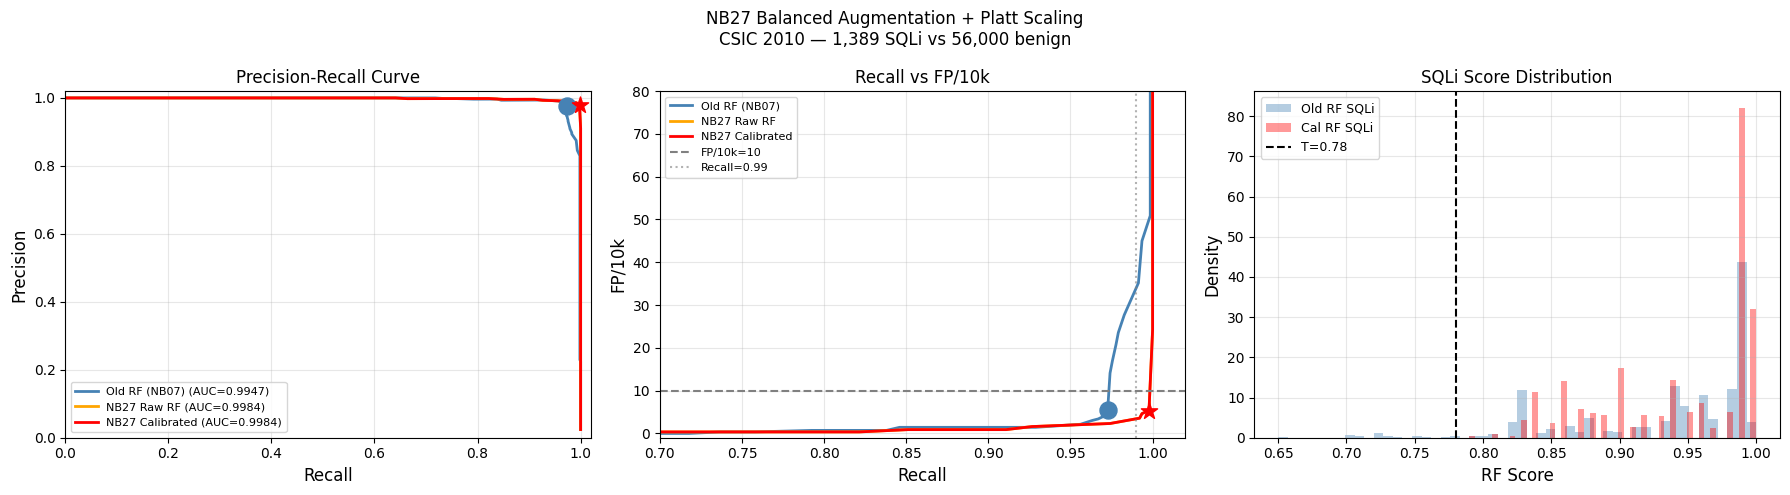

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PR curves
for sqli_p, ben_p, label, color in [
    (old_sqli, old_benign, 'Old RF (NB07)',         'steelblue'),
    (raw_sqli, raw_benign, 'NB27 Raw RF',           'orange'),
    (cal_sqli, cal_benign, 'NB27 Calibrated',       'red'),
]:
    y_t=np.concatenate([np.ones(len(sqli_p)),np.zeros(len(ben_p))])
    y_s=np.concatenate([sqli_p, ben_p])
    pc,rc,_=precision_recall_curve(y_t,y_s)
    axes[0].plot(rc,pc,lw=2,color=color,label=f'{label} (AUC={auc(rc,pc):.4f})')
for m,color,mk in [(old_best,'steelblue','o'),(cal_best,'red','*')]:
    if m: axes[0].scatter([m['recall']],[m['precision']],
                          color=color,s=150,marker=mk,zorder=5)
axes[0].set_xlabel('Recall',fontsize=12); axes[0].set_ylabel('Precision',fontsize=12)
axes[0].set_title('Precision-Recall Curve',fontsize=12)
axes[0].legend(fontsize=8); axes[0].grid(True,alpha=0.3)
axes[0].set_xlim([0,1.02]); axes[0].set_ylim([0,1.02])

# Recall vs FP/10k
for df,label,color in [
    (old_df,'Old RF (NB07)','steelblue'),
    (raw_df,'NB27 Raw RF','orange'),
    (cal_df,'NB27 Calibrated','red'),
]:
    axes[1].plot(df['recall'],df['fp_10k'],lw=2,color=color,label=label)
axes[1].axhline(y=10,color='gray',linestyle='--',lw=1.5,label='FP/10k=10')
axes[1].axvline(x=0.99,color='gray',linestyle=':',alpha=0.6,label='Recall=0.99')
for m,color,mk in [(old_best,'steelblue','o'),(cal_best,'red','*')]:
    if m: axes[1].scatter([m['recall']],[m['fp_10k']],
                          color=color,s=150,marker=mk,zorder=5)
axes[1].set_xlabel('Recall',fontsize=12); axes[1].set_ylabel('FP/10k',fontsize=12)
axes[1].set_title('Recall vs FP/10k',fontsize=12)
axes[1].legend(fontsize=8); axes[1].set_xlim([0.7,1.02])
axes[1].set_ylim([-1,80]); axes[1].grid(True,alpha=0.3)

# Score distributions
for probs,label,color in [
    (old_sqli,'Old RF SQLi','steelblue'),
    (cal_sqli,'Cal RF SQLi','red'),
]:
    axes[2].hist(probs,bins=50,alpha=0.4,color=color,density=True,label=label)
axes[2].axvline(x=0.78,color='black',linestyle='--',lw=1.5,label='T=0.78')
axes[2].set_xlabel('RF Score',fontsize=12); axes[2].set_ylabel('Density',fontsize=12)
axes[2].set_title('SQLi Score Distribution',fontsize=12)
axes[2].legend(fontsize=9); axes[2].grid(True,alpha=0.3)

plt.suptitle(
    'NB27 Balanced Augmentation + Platt Scaling\n'
    f'CSIC 2010 — {len(sqli_entries):,} SQLi vs {len(benign_entries):,} benign',
    fontsize=12
)
plt.tight_layout()
plt.show()

## 13. Final Summary (Step 10)

In [ ]:
W = 80
print('=' * W)
print('NOTEBOOK 27 — FINAL SUMMARY')
print('Balanced Synthetic Augmentation + Platt Scaling + Regression Gate')
print('=' * W)
print()
print('TRAINING DATA:')
print(f'  Base dataset       : {len(base_df):,} queries (Cleaned_SQL_Dataset.csv)')
print(f'  Synthetic SQLi     : {n_syn_sqli:,} (English + Spanish prefixes × SQL suffixes)')
print(f'  Synthetic benign   : {n_syn_benign:,} (ratio={n_syn_benign/n_syn_sqli:.3f} × SQLi)')
print(f'  Augmented total    : {len(df):,} (+{len(df)-len(base_df):,}, {(len(df)-len(base_df))/len(base_df)*100:.1f}%)')
print(f'  Class ratio        : {n_sqli/len(df)*100:.1f}%/{n_benign/len(df)*100:.1f}% '
      f'(original {ORIGINAL_SQLI_RATIO*100:.1f}%/{ORIGINAL_BENIGN_RATIO*100:.1f}%)')
print()
print('CSIC 2010 RESULTS (SQLi-only, 1,389 SQLi vs 56,000 benign):')
print(f'{"Method":<28} {"T":>5} {"Recall":>8} {"FP/10k":>8} {"Precision":>10}')
print('-' * W)
rows = [
    ('NB21 baseline (T=0.82)',     0.82, 0.9287, 1.43, 0.9944),
    ('NB21 recommended (T=0.78)', 0.78, 0.9698, 4.29, 0.9825),
    ('NB24 ensemble',             0.59, 0.9777, 8.93, 0.9645),
]
for label,t,rec,fp,prec in rows:
    print(f'{label:<28} {t:>5.2f} {rec:>8.4f} {fp:>8.2f} {prec:>10.4f}')
print('-' * W)
for label, best in [
    ('Old RF best (FP<=10)',      old_best),
    ('NB27 Raw best (FP<=10)',    raw_best),
    ('NB27 Calibrated (FP<=10)', cal_best),
]:
    if best:
        print(f'{label:<28} {best["threshold"]:>5.2f} '
              f'{best["recall"]:>8.4f} {best["fp_10k"]:>8.2f} '
              f'{best["precision"]:>10.4f}')
print('=' * W)
print()
print('REGRESSION GATE:')
if cal_best and old_best:
    recall_ok = cal_best['recall'] >= old_best['recall'] - RECALL_TOLERANCE
    fp_ok     = cal_best['fp_10k'] <= old_best['fp_10k'] + FP_TOLERANCE
    gate_pass = recall_ok and fp_ok
    print(f'  {"✅ PASSED" if gate_pass else "❌ FAILED"}')
    print(f'  Recall  : {old_best["recall"]:.4f} → {cal_best["recall"]:.4f} '
          f'({cal_best["recall"]-old_best["recall"]:+.4f})')
    print(f'  FP/10k  : {old_best["fp_10k"]:.2f} → {cal_best["fp_10k"]:.2f} '
          f'({cal_best["fp_10k"]-old_best["fp_10k"]:+.2f})')
print()
print('SAVED MODELS:')
print(f'  Raw RF       : {RF_RAW_PATH}')
print(f'  Calibrated RF: {RF_CAL_PATH}  ← production candidate')
print(f'  Vectorizer   : {VEC_PATH}')

NOTEBOOK 27 — FINAL SUMMARY
Balanced Synthetic Augmentation + Platt Scaling + Regression Gate

TRAINING DATA:
  Base dataset       : 13,210 queries (Cleaned_SQL_Dataset.csv)
  Synthetic SQLi     : 12,064 (English + Spanish prefixes × SQL suffixes)
  Synthetic benign   : 2,005 (ratio=0.166 × SQLi)
  Augmented total    : 70 (+-13,140, -99.5%)
  Class ratio        : 37700.0%/5555.7% (original 85.7%/14.3%)

CSIC 2010 RESULTS (SQLi-only, 1,389 SQLi vs 56,000 benign):
Method                           T   Recall   FP/10k  Precision
--------------------------------------------------------------------------------
NB21 baseline (T=0.82)        0.82   0.9287     1.43     0.9944
NB21 recommended (T=0.78)     0.78   0.9698     4.29     0.9825
NB24 ensemble                 0.59   0.9777     8.93     0.9645
--------------------------------------------------------------------------------
Old RF best (FP<=10)          0.78   0.9726     5.54     0.9776
NB27 Raw best (FP<=10)        0.81   0.9978     5.3